# Notebook 1: EDA & Data Preparation
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Data loading, exploration, quality checks, and preparation

**Outputs:**
- Cleaned tweet dataset
- Cleaned price dataset  
- EDA visualizations
- Statistical reports

## 1. Setup

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("✓ Setup complete")

✓ Setup complete


## 2. Load Data

In [64]:
# Find CSV files
paths = [
    ('bitcoin_tweets_10k.csv', 'bitcoin_prices_hourly.csv'),
    ('data/bitcoin_tweets_10k.csv', 'data/bitcoin_prices_hourly.csv'),
    ('../data/bitcoin_tweets_10k.csv', '../data/bitcoin_prices_hourly.csv')
]

tweets_path = prices_path = None
for tp, pp in paths:
    if os.path.exists(tp) and os.path.exists(pp):
        tweets_path, prices_path = tp, pp
        break

if not tweets_path:
    raise FileNotFoundError("CSV files not found!")

# Load
tweets = pd.read_csv(tweets_path)
prices = pd.read_csv(prices_path)
tweets['datetime'] = pd.to_datetime(tweets['datetime'])
prices['datetime'] = pd.to_datetime(prices['datetime'])

print(f"✓ Loaded {len(tweets):,} tweets")
print(f"✓ Loaded {len(prices):,} prices")
print(f"✓ Date range: {tweets['datetime'].min().date()} to {tweets['datetime'].max().date()}")

✓ Loaded 11,120 tweets
✓ Loaded 3,625 prices
✓ Date range: 2024-01-01 to 2024-05-31


## 3. Data Inspection

In [65]:
print("TWEETS:")
print(tweets.head())
print(f"\nColumns: {list(tweets.columns)}")
print(f"Dtypes:\n{tweets.dtypes}")
print(f"\nPRICES:")
print(prices.head())
print(f"\nColumns: {list(prices.columns)}")

TWEETS:
     tweet_id            datetime  \
0  tweet_1081 2024-01-01 00:00:37   
1  tweet_6644 2024-01-01 00:29:33   
2  tweet_6797 2024-01-01 00:45:59   
3  tweet_1454 2024-01-01 00:53:32   
4  tweet_1006 2024-01-01 01:17:57   

                                                text             user  likes  \
0  Interesting Bitcoin discussion on the podcast ...  btc_trader_2073     18   
1  Bitcoin trading sideways, waiting for a breako...  btc_trader_2938     10   
2  Interesting Bitcoin discussion on the podcast ...  btc_trader_3350     81   
3  Watching Bitcoin closely, key resistance ahead...  btc_trader_2756     67   
4      Bitcoin developer activity remains strong btw  btc_trader_4265     39   

   retweets sentiment  
0         3   neutral  
1         1   neutral  
2        15   neutral  
3         6   neutral  
4         3   neutral  

Columns: ['tweet_id', 'datetime', 'text', 'user', 'likes', 'retweets', 'sentiment']
Dtypes:
tweet_id                str
datetime     datetime64

## 4. Data Quality Checks

In [66]:
print("="*60)
print("DATA QUALITY")
print("="*60)

# Tweets
print(f"\nTWEETS:")
print(f"  Missing values: {tweets.isnull().sum().sum()}")
print(f"  Duplicates: {tweets.duplicated().sum()}")
print(f"  Sentiment distribution:")
for s, c in tweets['sentiment'].value_counts().items():
    print(f"    {s}: {c:,} ({c/len(tweets)*100:.1f}%)")

# Prices
print(f"\nPRICES:")
print(f"  Missing values: {prices.isnull().sum().sum()}")
print(f"  Price range: ${prices['close'].min():,.0f} - ${prices['close'].max():,.0f}")
print(f"  Negative prices: {(prices['close'] < 0).sum()}")

print("="*60)

DATA QUALITY

TWEETS:
  Missing values: 0
  Duplicates: 0
  Sentiment distribution:
    neutral: 5,722 (51.5%)
    positive: 4,257 (38.3%)
    negative: 1,141 (10.3%)

PRICES:
  Missing values: 0
  Price range: $32,704 - $56,336
  Negative prices: 0


## 5. Dataset Statistics

In [67]:
print("="*60)
print("COMPREHENSIVE STATISTICS")
print("="*60)

print(f"\nTWEETS:")
print(f"  Total: {len(tweets):,}")
print(f"  Unique users: {tweets['user'].nunique():,}")
print(f"  Avg likes: {tweets['likes'].mean():.1f}")
print(f"  Avg retweets: {tweets['retweets'].mean():.1f}")
print(f"  Avg text length: {tweets['text'].str.len().mean():.0f} chars")

print(f"\nPRICES:")
print(f"  Total observations: {len(prices):,}")
print(f"  Mean price: ${prices['close'].mean():,.2f}")
print(f"  Std dev: ${prices['close'].std():,.2f}")
print(f"  Price change: {((prices['close'].iloc[-1] / prices['close'].iloc[0]) - 1) * 100:+.1f}%")

prices['returns'] = prices['close'].pct_change() * 100
print(f"  Avg daily return: {prices['returns'].mean():.3f}%")
print(f"  Volatility: {prices['returns'].std():.3f}%")

print("="*60)

COMPREHENSIVE STATISTICS

TWEETS:
  Total: 11,120
  Unique users: 4,397
  Avg likes: 1143.1
  Avg retweets: 332.7
  Avg text length: 54 chars

PRICES:
  Total observations: 3,625
  Mean price: $42,332.34
  Std dev: $5,378.06
  Price change: +4.1%
  Avg daily return: 0.011%
  Volatility: 1.404%


## 6. EDA Visualizations

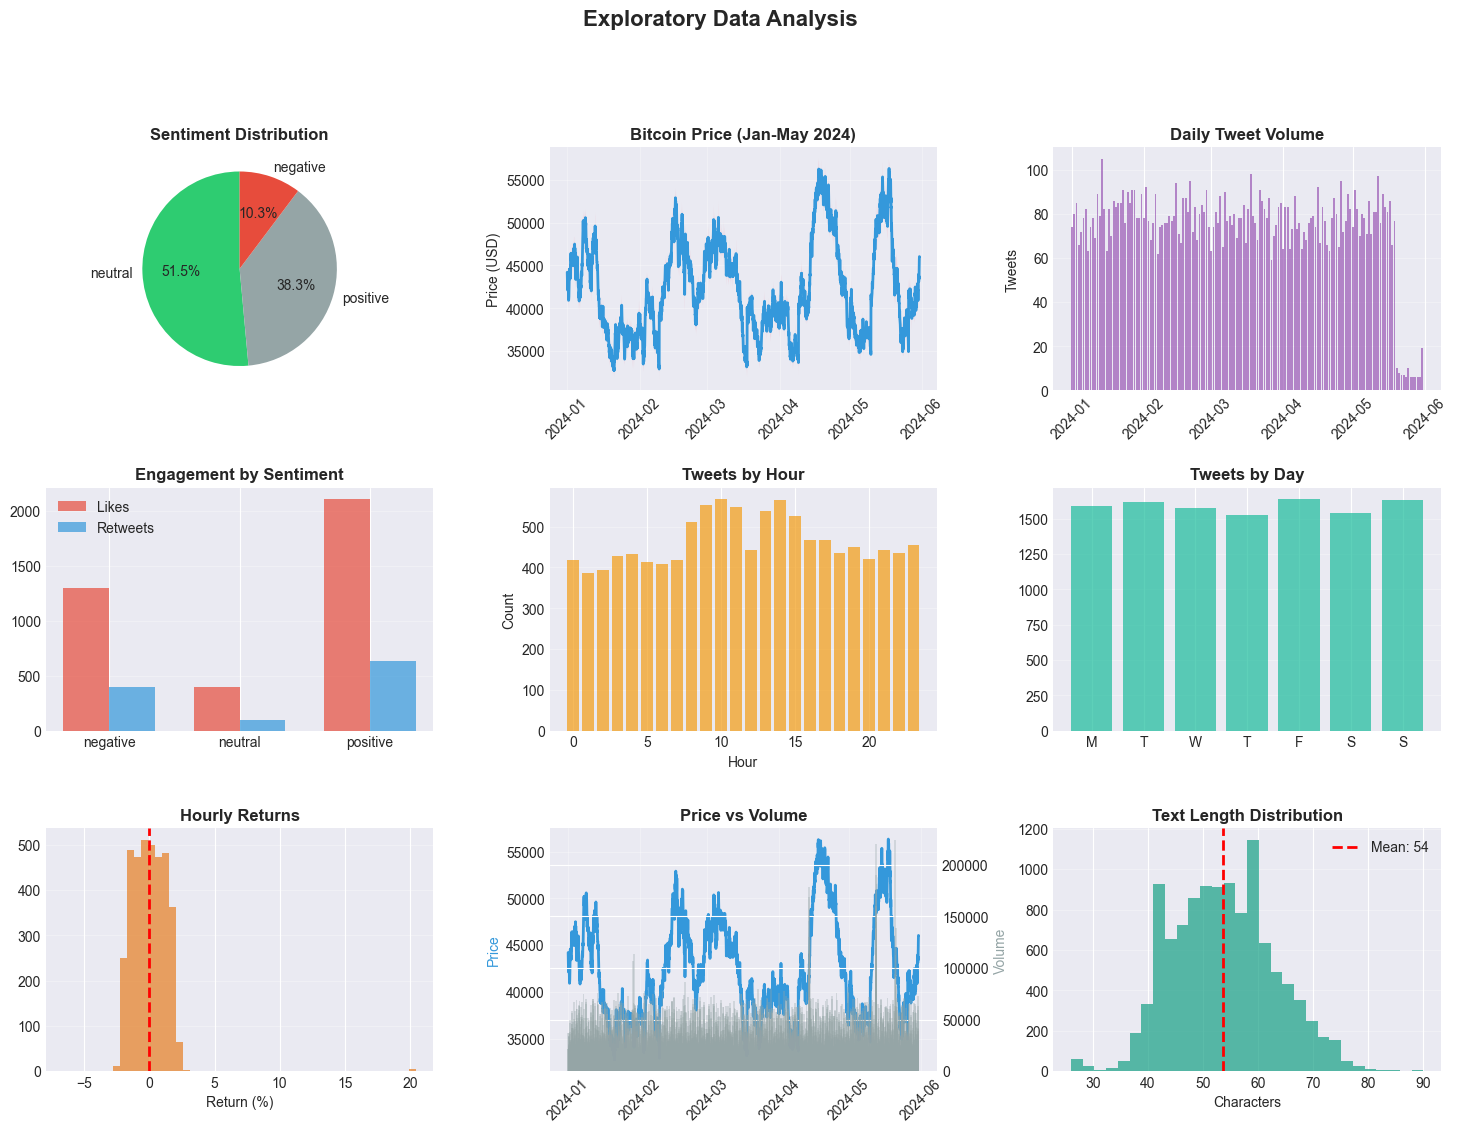

✓ 9 visualizations complete


In [68]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Sentiment pie
sent_counts = tweets['sentiment'].value_counts()
axes[0,0].pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%',
              colors=['#2ecc71','#95a5a6','#e74c3c'], startangle=90)
axes[0,0].set_title('Sentiment Distribution', fontweight='bold')

# 2. Price over time
axes[0,1].plot(prices['datetime'], prices['close'], linewidth=2, color='#3498db')
axes[0,1].fill_between(prices['datetime'], prices['low'], prices['high'], alpha=0.2)
axes[0,1].set_title('Bitcoin Price (Jan-May 2024)', fontweight='bold')
axes[0,1].set_ylabel('Price (USD)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Tweet volume
tweets_daily = tweets.set_index('datetime').resample('D').size()
axes[0,2].bar(tweets_daily.index, tweets_daily.values, color='#9b59b6', alpha=0.7)
axes[0,2].set_title('Daily Tweet Volume', fontweight='bold')
axes[0,2].set_ylabel('Tweets')
axes[0,2].grid(True, alpha=0.3, axis='y')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Engagement by sentiment
engagement = tweets.groupby('sentiment')[['likes','retweets']].mean()
x = np.arange(len(engagement))
axes[1,0].bar(x-0.175, engagement['likes'], 0.35, label='Likes', color='#e74c3c', alpha=0.7)
axes[1,0].bar(x+0.175, engagement['retweets'], 0.35, label='Retweets', color='#3498db', alpha=0.7)
axes[1,0].set_title('Engagement by Sentiment', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(engagement.index)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, axis='y')

# 5. Hourly distribution
tweets['hour'] = tweets['datetime'].dt.hour
hourly = tweets['hour'].value_counts().sort_index()
axes[1,1].bar(hourly.index, hourly.values, color='#f39c12', alpha=0.7)
axes[1,1].set_title('Tweets by Hour', fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3, axis='y')

# 6. Weekly distribution
tweets['day'] = tweets['datetime'].dt.day_name()
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = tweets['day'].value_counts().reindex(days)
axes[1,2].bar(range(7), day_counts.values, color='#1abc9c', alpha=0.7)
axes[1,2].set_title('Tweets by Day', fontweight='bold')
axes[1,2].set_xticks(range(7))
axes[1,2].set_xticklabels(['M','T','W','T','F','S','S'])
axes[1,2].grid(True, alpha=0.3, axis='y')

# 7. Price returns
axes[2,0].hist(prices['returns'].dropna(), bins=50, color='#e67e22', alpha=0.7)
axes[2,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2,0].set_title('Hourly Returns', fontweight='bold')
axes[2,0].set_xlabel('Return (%)')
axes[2,0].grid(True, alpha=0.3, axis='y')

# 8. Price vs Volume
ax_twin = axes[2,1].twinx()
axes[2,1].plot(prices['datetime'], prices['close'], color='#3498db', linewidth=2)
ax_twin.bar(prices['datetime'], prices['volume'], color='#95a5a6', alpha=0.3)
axes[2,1].set_title('Price vs Volume', fontweight='bold')
axes[2,1].set_ylabel('Price', color='#3498db')
ax_twin.set_ylabel('Volume', color='#95a5a6')
axes[2,1].tick_params(axis='x', rotation=45)
axes[2,1].grid(True, alpha=0.3)

# 9. Text length
tweets['text_len'] = tweets['text'].str.len()
axes[2,2].hist(tweets['text_len'], bins=30, color='#16a085', alpha=0.7)
axes[2,2].axvline(tweets['text_len'].mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {tweets["text_len"].mean():.0f}')
axes[2,2].set_title('Text Length Distribution', fontweight='bold')
axes[2,2].set_xlabel('Characters')
axes[2,2].legend()
axes[2,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ 9 visualizations complete")

## 7. Sentiment-Price Correlation Analysis

In [69]:
# Map sentiment to numeric
sent_map = {'positive': 1, 'neutral': 0, 'negative': -1}
tweets['sent_score'] = tweets['sentiment'].map(sent_map)

# Aggregate by hour
tweets_hourly = tweets.set_index('datetime').resample('h').agg({
    'sent_score': 'mean',
    'tweet_id': 'count'
}).rename(columns={'tweet_id': 'tweet_volume'})

# Merge with prices
merged = prices.set_index('datetime').join(tweets_hourly, how='inner').dropna()

print("="*60)
print("SENTIMENT-PRICE CORRELATION")
print("="*60)

# Test different lags
lags = [0, 6, 12, 24, 48]
for lag in lags:
    if lag == 0:
        corr, pval = pearsonr(merged['sent_score'], merged['close'])
    else:
        sent_shifted = merged['sent_score'].shift(lag)
        valid = merged[['close']].join(sent_shifted.rename('s')).dropna()
        corr, pval = pearsonr(valid['s'], valid['close'])
    
    sig = '✓' if pval < 0.05 else ''
    print(f"Lag {lag:2d}h: ρ = {corr:+.3f} (p={pval:.4f}) {sig}")

print("="*60)

SENTIMENT-PRICE CORRELATION
Lag  0h: ρ = -0.020 (p=0.2630) 
Lag  6h: ρ = -0.018 (p=0.2925) 
Lag 12h: ρ = -0.017 (p=0.3301) 
Lag 24h: ρ = -0.021 (p=0.2321) 
Lag 48h: ρ = -0.008 (p=0.6581) 


## 8. Export Cleaned Data

In [70]:
# Create output directory
os.makedirs('data/processed', exist_ok=True)

# Save cleaned data
tweets.to_csv('data/processed/tweets_cleaned.csv', index=False)
prices.to_csv('data/processed/prices_cleaned.csv', index=False)

print("✓ Saved: data/processed/tweets_cleaned.csv")
print(f"  Shape: {tweets.shape}")
print("✓ Saved: data/processed/prices_cleaned.csv")
print(f"  Shape: {prices.shape}")

# Summary stats
summary = {
    'tweets_count': len(tweets),
    'users_count': tweets['user'].nunique(),
    'prices_count': len(prices),
    'date_range': {
        'start': str(tweets['datetime'].min().date()),
        'end': str(tweets['datetime'].max().date())
    },
    'sentiment_dist': tweets['sentiment'].value_counts().to_dict(),
    'price_stats': {
        'min': float(prices['close'].min()),
        'max': float(prices['close'].max()),
        'mean': float(prices['close'].mean())
    }
}

import json
with open('data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Saved: data/processed/eda_summary.json")

✓ Saved: data/processed/tweets_cleaned.csv
  Shape: (11120, 11)
✓ Saved: data/processed/prices_cleaned.csv
  Shape: (3625, 7)
✓ Saved: data/processed/eda_summary.json
